Epoch 1/700 - Train Loss: 0.2852 - Val Loss: 0.0348
Epoch 2/700 - Train Loss: 0.0951 - Val Loss: 0.0422
Epoch 3/700 - Train Loss: 0.0496 - Val Loss: 0.0450
Epoch 4/700 - Train Loss: 0.0695 - Val Loss: 0.0147
Epoch 5/700 - Train Loss: 0.0424 - Val Loss: 0.0103
Epoch 6/700 - Train Loss: 0.0357 - Val Loss: 0.0058
Epoch 7/700 - Train Loss: 0.0319 - Val Loss: 0.0124
Epoch 8/700 - Train Loss: 0.0291 - Val Loss: 0.0047
Epoch 9/700 - Train Loss: 0.0314 - Val Loss: 0.0045
Epoch 10/700 - Train Loss: 0.0228 - Val Loss: 0.0099
Epoch 11/700 - Train Loss: 0.0229 - Val Loss: 0.0046
Epoch 12/700 - Train Loss: 0.0189 - Val Loss: 0.0042
Epoch 13/700 - Train Loss: 0.0166 - Val Loss: 0.0056
Epoch 14/700 - Train Loss: 0.0141 - Val Loss: 0.0044
Epoch 15/700 - Train Loss: 0.0152 - Val Loss: 0.0041
Epoch 16/700 - Train Loss: 0.0127 - Val Loss: 0.0049
Epoch 17/700 - Train Loss: 0.0125 - Val Loss: 0.0039
Epoch 18/700 - Train Loss: 0.0147 - Val Loss: 0.0048
Epoch 19/700 - Train Loss: 0.0102 - Val Loss: 0.0044
Ep

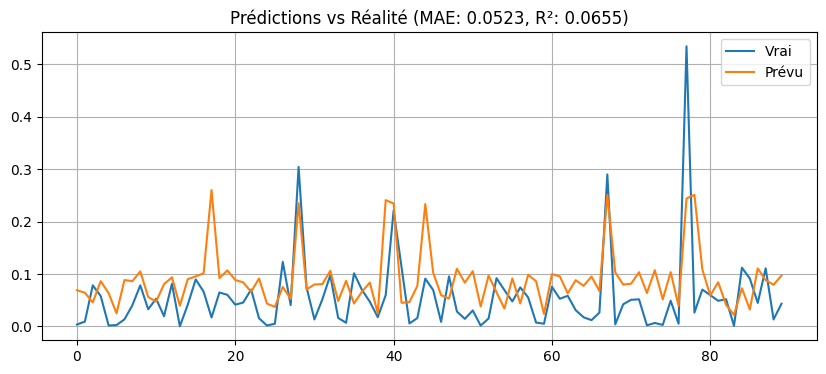

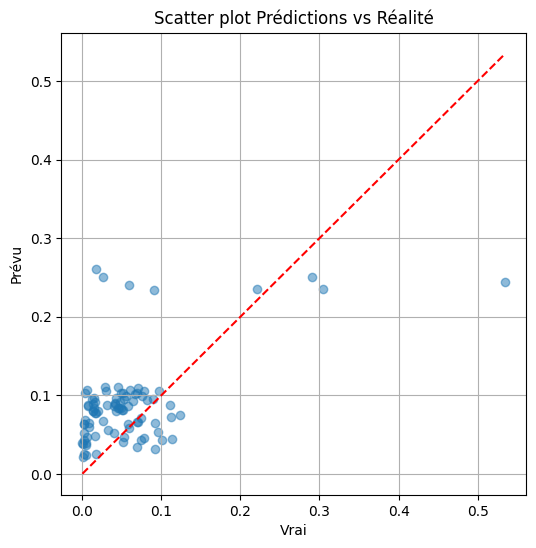

In [7]:
# 📚 Imports
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

# 📁 Chargement du jeu de données
raw_df = pd.read_csv("scaled_dataset.csv")

# ✅ Normalisation de la cible (juste au cas où)
scaler_y = MinMaxScaler()
raw_df['production'] = scaler_y.fit_transform(raw_df[['production']])

# 🔄 Séquences temporelles
window_size = 24  # fenêtre de 2 jours horaires

def create_sequences(data, target_column):
    X, y = [], []
    for i in range(0, len(data) - window_size, window_size):
        X.append(data.iloc[i:i+window_size].values)
        y.append(data.iloc[i+window_size][target_column])
    return np.array(X), np.array(y)

X, y = create_sequences(raw_df, 'production')

# 📎 Split Train/Val/Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# 📦 Dataset PyTorch
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=64, shuffle=False)

# 🔧 Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# 🧠 Transformer amélioré (version allégée)
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=4, dim_feedforward=128, dropout=0.2):
        super().__init__()
        self.input_linear = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(d_model, 1)

    def forward(self, src):
        x = self.input_linear(src)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.regressor(x)

# ⚙️ Entraînement avec EarlyStopping et validation
model = TransformerRegressor(input_dim=X_train.shape[2])
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005)

n_epochs = 700
best_val_loss = float('inf')
patience = 15  # on augmente un peu patience vu qu'on a plus de couches
patience_counter = 0

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping déclenché")
            break

# 📊 Évaluation finale
model.eval()
preds, truths = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb).cpu().numpy()
        preds.extend(pred)
        truths.extend(yb.numpy())

preds = np.array(preds).flatten()
truths = np.array(truths).flatten()

mae = mean_absolute_error(truths, preds)
r2 = r2_score(truths, preds)

print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# ➡️ Plot time series
plt.figure(figsize=(10,4))
plt.plot(truths[:200], label="Vrai")
plt.plot(preds[:200], label="Prévu")
plt.legend()
plt.title(f"Prédictions vs Réalité (MAE: {mae:.4f}, R²: {r2:.4f})")
plt.grid(True)
plt.show()

# ➡️ Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(truths, preds, alpha=0.5)
plt.plot([truths.min(), truths.max()], [truths.min(), truths.max()], 'r--')
plt.xlabel("Vrai")
plt.ylabel("Prévu")
plt.title("Scatter plot Prédictions vs Réalité")
plt.grid(True)
plt.show()

In [11]:
# ========================================
# Temporal Fusion Transformer V5
# Entraînement sur l'ensemble du dataset
# Prédiction de la production PV (prochain jour)
# Auteur : Saman ISMAIL
# ========================================

# === Imports ===
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# === Chargement des données ===
df = pd.read_csv("full_dataset.csv", sep=";")
df['date1'] = pd.to_datetime(df['date'], dayfirst=True)

# Ajout de features temporelles cycliques
df['dayofyear'] = df['date1'].dt.dayofyear
df['weekofyear'] = df['date1'].dt.isocalendar().week.astype(int)
df['year'] = df['date1'].dt.year

df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
df['weekofyear_sin'] = np.sin(2 * np.pi * df['weekofyear'] / 52)
df['weekofyear_cos'] = np.cos(2 * np.pi * df['weekofyear'] / 52)
df['year_mod'] = (df['year'] - df['year'].min()) % 3
df['year_sin'] = np.sin(2 * np.pi * df['year_mod'] / 3)
df['year_cos'] = np.cos(2 * np.pi * df['year_mod'] / 3)

# Nettoyage
df.drop(columns=['date', 'date1', 'dayofyear', 'weekofyear', 'year', 'year_mod'], inplace=True)

# Normalisation de la cible
scaler_y = MinMaxScaler()
df['production'] = scaler_y.fit_transform(df[['production']])

# === Construction des séquences temporelles ===
window_size = 30  # Nombre de jours dans la fenêtre (ici 1 mois)
step_size = 1     # Décalage de la fenêtre (ici 1 jour)

def create_sequences(data, target_column):
    X, y = [], []
    for i in range(0, len(data) - window_size, step_size):
        X.append(data.iloc[i:i+window_size].values)
        y.append(data.iloc[i+window_size][target_column])
    return np.array(X), np.array(y)

X, y = create_sequences(df, 'production')

# Conversion en Tensors
X_train = torch.tensor(X, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# On prépare aussi la dernière fenêtre pour prédire le "jour suivant"
X_last = torch.tensor(df.iloc[-window_size:].values[np.newaxis, :, :], dtype=torch.float32)

# === Dataset PyTorch ===
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=64, shuffle=True)

# === Modules TFT V5 ===
# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# GRN (Gated Residual Network)
class GRN(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_dim, input_dim)
        self.dropout = nn.Dropout(dropout)
        self.gate = nn.GLU()
        self.layer_norm = nn.LayerNorm(input_dim)
    def forward(self, x):
        residual = x
        x = self.fc1(x)
        x = self.elu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.gate(torch.cat([x, residual], dim=-1))
        x = self.layer_norm(x + residual)
        return x

# Variable Selection Network
class VSN(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, hidden_dim)
        self.elu = nn.ELU()
        self.context_gate = nn.Linear(hidden_dim, input_dim)
        self.softmax = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x_proj = self.linear(x)
        x_proj = self.elu(x_proj)
        gates = self.context_gate(x_proj)
        gates = self.softmax(gates)
        x_weighted = x * gates
        return self.dropout(x_weighted)

# === Architecture TFT V5 complète ===
class TemporalFusionTransformerV5(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=3, dim_feedforward=512, dropout=0.2, gru_hidden_size=128):
        super().__init__()
        self.vsn = VSN(input_dim, hidden_dim=128, dropout=dropout)
        self.input_linear = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.grn = GRN(d_model, dim_feedforward, dropout=dropout)
        self.gru = nn.GRU(input_size=d_model, hidden_size=gru_hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(gru_hidden_size, 1)

    def forward(self, src):
        src = self.vsn(src)
        x = self.input_linear(src)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.grn(x)
        x, _ = self.gru(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        return self.regressor(x)

# === Entraînement complet ===
model = TemporalFusionTransformerV5(input_dim=X_train.shape[2])
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

n_epochs = 700
best_train_loss = float('inf')
patience = 20
patience_counter = 0

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {avg_train_loss:.5f} - LR: {optimizer.param_groups[0]['lr']:.6f}")

    scheduler.step(avg_train_loss)

    if avg_train_loss < best_train_loss:
        best_train_loss = avg_train_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_tft_full.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping déclenché")
            break

# === Prédiction du jour suivant ===
model.load_state_dict(torch.load("best_tft_full.pt"))
model.eval()

with torch.no_grad():
    pred_next_day = model(X_last).cpu().numpy().flatten()[0]
    pred_next_day_inv = scaler_y.inverse_transform([[pred_next_day]])[0,0]

print(f"⚡️ Prédiction production pour le prochain jour : {pred_next_day_inv:.2f} kWh")


Epoch 1/700 - Train Loss: 0.01045 - LR: 0.000500
Epoch 2/700 - Train Loss: 0.00616 - LR: 0.000500
Epoch 3/700 - Train Loss: 0.00602 - LR: 0.000500
Epoch 4/700 - Train Loss: 0.00603 - LR: 0.000500
Epoch 5/700 - Train Loss: 0.00581 - LR: 0.000500
Epoch 6/700 - Train Loss: 0.00570 - LR: 0.000500
Epoch 7/700 - Train Loss: 0.00566 - LR: 0.000500
Epoch 8/700 - Train Loss: 0.00564 - LR: 0.000500
Epoch 9/700 - Train Loss: 0.00559 - LR: 0.000500
Epoch 10/700 - Train Loss: 0.00563 - LR: 0.000500
Epoch 11/700 - Train Loss: 0.00557 - LR: 0.000500
Epoch 12/700 - Train Loss: 0.00554 - LR: 0.000500
Epoch 13/700 - Train Loss: 0.00555 - LR: 0.000500
Epoch 14/700 - Train Loss: 0.00549 - LR: 0.000500
Epoch 15/700 - Train Loss: 0.00550 - LR: 0.000500
Epoch 16/700 - Train Loss: 0.00547 - LR: 0.000500
Epoch 17/700 - Train Loss: 0.00552 - LR: 0.000500
Epoch 18/700 - Train Loss: 0.00546 - LR: 0.000500
Epoch 19/700 - Train Loss: 0.00545 - LR: 0.000500
Epoch 20/700 - Train Loss: 0.00545 - LR: 0.000500
Epoch 21/

KeyboardInterrupt: 